# Energy Consumption EDA
Exploratory analysis of the UCI household power consumption dataset.
Run after completing ingest + feature pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/features/features.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (33999, 13)


,consumption_kwh,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_7d,rolling_std_24h,hour,day_of_week,month,is_weekend,is_holiday,target
datetime,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,4.349100,1.496800,4.222889,2.934890,1.763946,0.990187,17,5,12,1,0,3.879400
2006-12-23 18:00:00,3.879400,5.452533,2.686967,3.632200,3.099713,1.771265,1.066674,18,5,12,1,0,4.117833
2006-12-23 19:00:00,4.117833,3.879400,3.938167,3.400233,3.149397,1.772736,1.074356,19,5,12,1,0,4.181400
2006-12-23 20:00:00,4.181400,4.117833,3.536067,3.268567,3.156883,1.777008,1.080699,20,5,12,1,0,3.288433
2006-12-23 21:00:00,3.288433,4.181400,4.548667,3.056467,3.183772,1.782441,1.098426,21,5,12,1,0,4.327933


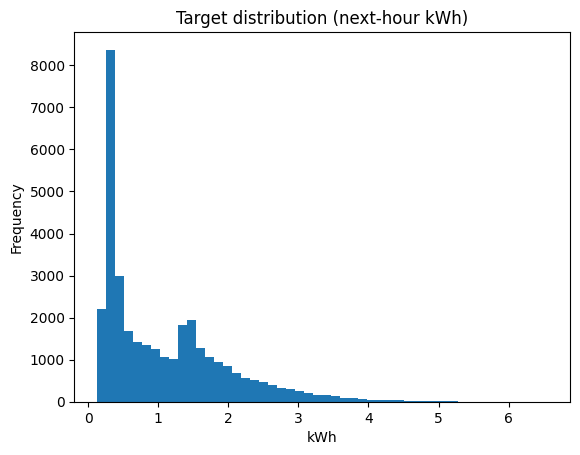

In [2]:
df['target'].plot(kind='hist', bins=50, title='Target distribution (next-hour kWh)')
plt.xlabel('kWh')
plt.show()

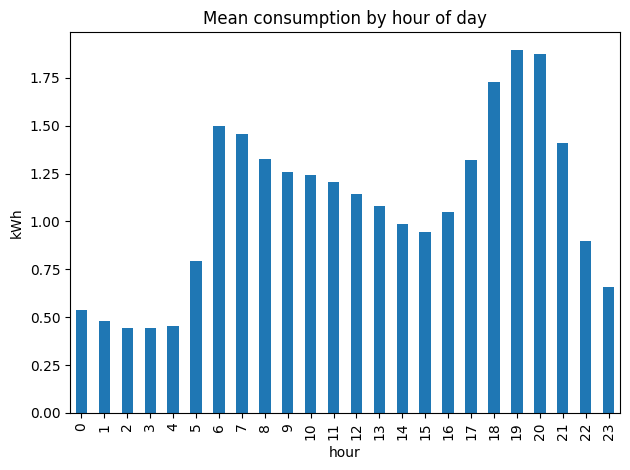

In [3]:
df.groupby('hour')['target'].mean().plot(
    kind='bar', title='Mean consumption by hour of day'
)
plt.ylabel('kWh')
plt.tight_layout()
plt.show()

In [4]:
df[['lag_1h', 'lag_24h', 'lag_168h', 'target']].corr().round(3)

,lag_1h,lag_24h,lag_168h,target
lag_1h,1.000,0.375,0.394,0.463
lag_24h,0.375,1.000,0.387,0.383
lag_168h,0.394,0.387,1.000,0.387
target,0.463,0.383,0.387,1.000


## Step 1: Diagnose — Why is MAPE so high?

In [ ]:
print("=== Target distribution ===")
print(df['target'].describe().round(4))
print()
print("=== Key quantiles ===")
print(df['target'].quantile([0.01, 0.05, 0.10, 0.25, 0.50]).round(4))
print()

# How many rows have target < 0.2 kW? These are the ones destroying MAPE
low_values = (df['target'] < 0.2).sum()
pct = low_values / len(df) * 100
print(f"Rows with target < 0.2 kW: {low_values} ({pct:.1f}% of data)")
print()

# Simulate what MAPE looks like with and without near-zero rows
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# Use lag_1h as a naive "model" to get ballpark MAPE
naive_pred = df['lag_1h'].values
actual = df['target'].values

mape_all = mean_absolute_percentage_error(actual, naive_pred)
mask = actual >= 0.2
mape_filtered = mean_absolute_percentage_error(actual[mask], naive_pred[mask])

print(f"Naive model MAPE (all rows):          {mape_all:.1%}")
print(f"Naive model MAPE (target >= 0.2 kW):  {mape_filtered:.1%}")
print()
print("If these two numbers differ a lot, MAPE is being skewed by near-zero values.")

## Step 2: Fourier Features — Encoding Cyclical Patterns

In [ ]:
import numpy as np

# Why Fourier? The model sees 'hour' as integers: 0, 1, 2...23
# It treats hour 23 and hour 0 as far apart — but they're adjacent.
# Fourier encodes the cycle: sin/cos map the integers onto a circle.

df_fourier = df.copy()
df_fourier['hour_sin'] = np.sin(2 * np.pi * df_fourier.index.hour / 24)
df_fourier['hour_cos'] = np.cos(2 * np.pi * df_fourier.index.hour / 24)
df_fourier['dow_sin']  = np.sin(2 * np.pi * df_fourier.index.dayofweek / 7)
df_fourier['dow_cos']  = np.cos(2 * np.pi * df_fourier.index.dayofweek / 7)
df_fourier['month_sin'] = np.sin(2 * np.pi * df_fourier.index.month / 12)
df_fourier['month_cos'] = np.cos(2 * np.pi * df_fourier.index.month / 12)

# Visualise: does hour_sin/cos correlate better with target than raw hour?
fourier_cols = ['hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
corr = df_fourier[fourier_cols + ['target']].corr()['target'].drop('target').round(3)
print("Correlation with target:")
print(corr.to_string())
print()

# Plot: raw hour vs hour_sin to show the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_fourier.groupby('hour')['target'].mean().plot(
    kind='bar', ax=axes[0], title='Target by raw hour (integers — gap at 0/23)')
axes[0].set_ylabel('Mean kWh')

hour_sample = df_fourier[['hour_sin', 'hour_cos']].drop_duplicates().sort_values('hour_sin')
axes[1].scatter(hour_sample['hour_sin'], hour_sample['hour_cos'], color='steelblue')
axes[1].set_title('hour_sin vs hour_cos — continuous circle, no gap')
axes[1].set_xlabel('hour_sin'); axes[1].set_ylabel('hour_cos')

plt.tight_layout()
plt.show()

In [ ]:
# Quick model comparison: original features vs + Fourier features
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

ORIGINAL_FEATURES = [
    'lag_1h', 'lag_24h', 'lag_168h',
    'rolling_mean_24h', 'rolling_mean_7d', 'rolling_std_24h',
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
]
FOURIER_FEATURES = ORIGINAL_FEATURES + [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

n = len(df_fourier)
train_end, val_end = int(n * 0.70), int(n * 0.85)

def quick_eval(feature_cols, label):
    X_tr = df_fourier[feature_cols].iloc[:train_end]
    y_tr = df_fourier['target'].iloc[:train_end]
    X_val = df_fourier[feature_cols].iloc[train_end:val_end]
    y_val = df_fourier['target'].iloc[train_end:val_end]
    X_te = df_fourier[feature_cols].iloc[val_end:]
    y_te = df_fourier['target'].iloc[val_end:]

    m = LGBMRegressor(num_leaves=63, learning_rate=0.05, n_estimators=300,
                      subsample=0.8, verbosity=-1)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    preds = m.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    print(f"{label:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse

rmse_orig   = quick_eval(ORIGINAL_FEATURES, "Original features")
rmse_fourier = quick_eval(FOURIER_FEATURES,  "Original + Fourier")

improvement = (rmse_orig - rmse_fourier) / rmse_orig * 100
print(f"\nFourier improvement: {improvement:+.2f}%")

## Step 3: Better Lag & Range Features

In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_base = pd.read_parquet('../data/features/features.parquet')

def add_extra_features(df):
    out = df.copy()
    src = out['consumption_kwh']
    shifted = src.shift(1)

    # Short-term momentum lags
    out['lag_2h']  = src.shift(2)
    out['lag_3h']  = src.shift(3)
    out['lag_48h'] = src.shift(48)

    # Range / volatility features
    out['rolling_max_24h']   = shifted.rolling(24).max()
    out['rolling_min_24h']   = shifted.rolling(24).min()
    out['rolling_range_24h'] = out['rolling_max_24h'] - out['rolling_min_24h']

    # Interaction: hour pattern differs on weekends vs weekdays
    out['hour_x_weekend'] = out.index.hour * (out.index.dayofweek >= 5).astype(int)

    return out.dropna()

df_ext = add_extra_features(df_base)
print(f"Rows after adding features: {len(df_ext)}  (was {len(df_base)})")

ORIGINAL = [
    'lag_1h','lag_24h','lag_168h',
    'rolling_mean_24h','rolling_mean_7d','rolling_std_24h',
    'hour','day_of_week','month','is_weekend','is_holiday',
]
EXTENDED = ORIGINAL + [
    'lag_2h','lag_3h','lag_48h',
    'rolling_max_24h','rolling_min_24h','rolling_range_24h',
    'hour_x_weekend',
]

n = len(df_ext)
tr, va = int(n * 0.70), int(n * 0.85)

def quick_eval(df, cols, label):
    params = dict(num_leaves=63, learning_rate=0.05, n_estimators=300, subsample=0.8, verbosity=-1)
    m = lgb.LGBMRegressor(**params)
    m.fit(
        df[cols].iloc[:tr], df['target'].iloc[:tr],
        eval_set=[(df[cols].iloc[tr:va], df['target'].iloc[tr:va])]
    )
    preds  = m.predict(df[cols].iloc[va:])
    actual = df['target'].iloc[va:].values
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    print(f"{label:40s}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse, m

rmse_orig, _     = quick_eval(df_ext, ORIGINAL, 'Original 11 features')
rmse_ext,  model = quick_eval(df_ext, EXTENDED,  'Extended 18 features')

print(f"\nImprovement: {(rmse_orig - rmse_ext) / rmse_orig * 100:+.2f}%")

Rows after adding features: 33951  (was 33999)
Original 11 features                      RMSE=0.5537  MAE=0.3960
Extended 18 features                      RMSE=0.5476  MAE=0.3933

Improvement: +1.10%


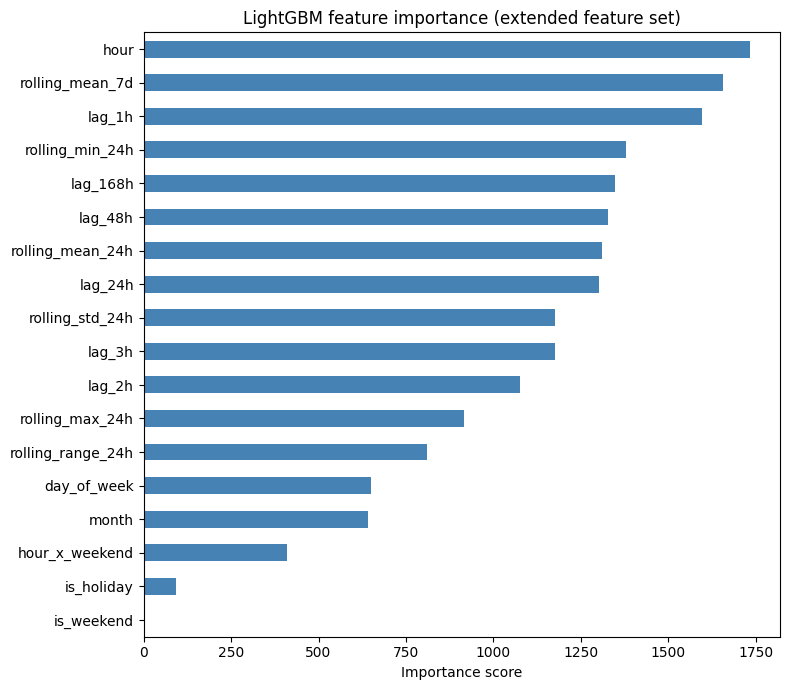

In [8]:
# Feature importance — which new features pulled their weight?
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=EXTENDED
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM feature importance (extended feature set)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()